# ANSER simulation in Python
A port of the MATLAB simulation with design considerations specific to python and future ML work.

---

### Imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import matplotlib.pyplot as plt


from anser import *
%matplotlib inline

---
## Coil Geometry Plots

### Single coil in local coordinate system

In [2]:
coil_local = coil_dimension_calc(consts.N_turns,consts.l,consts.w,consts.s,consts.z_thick)

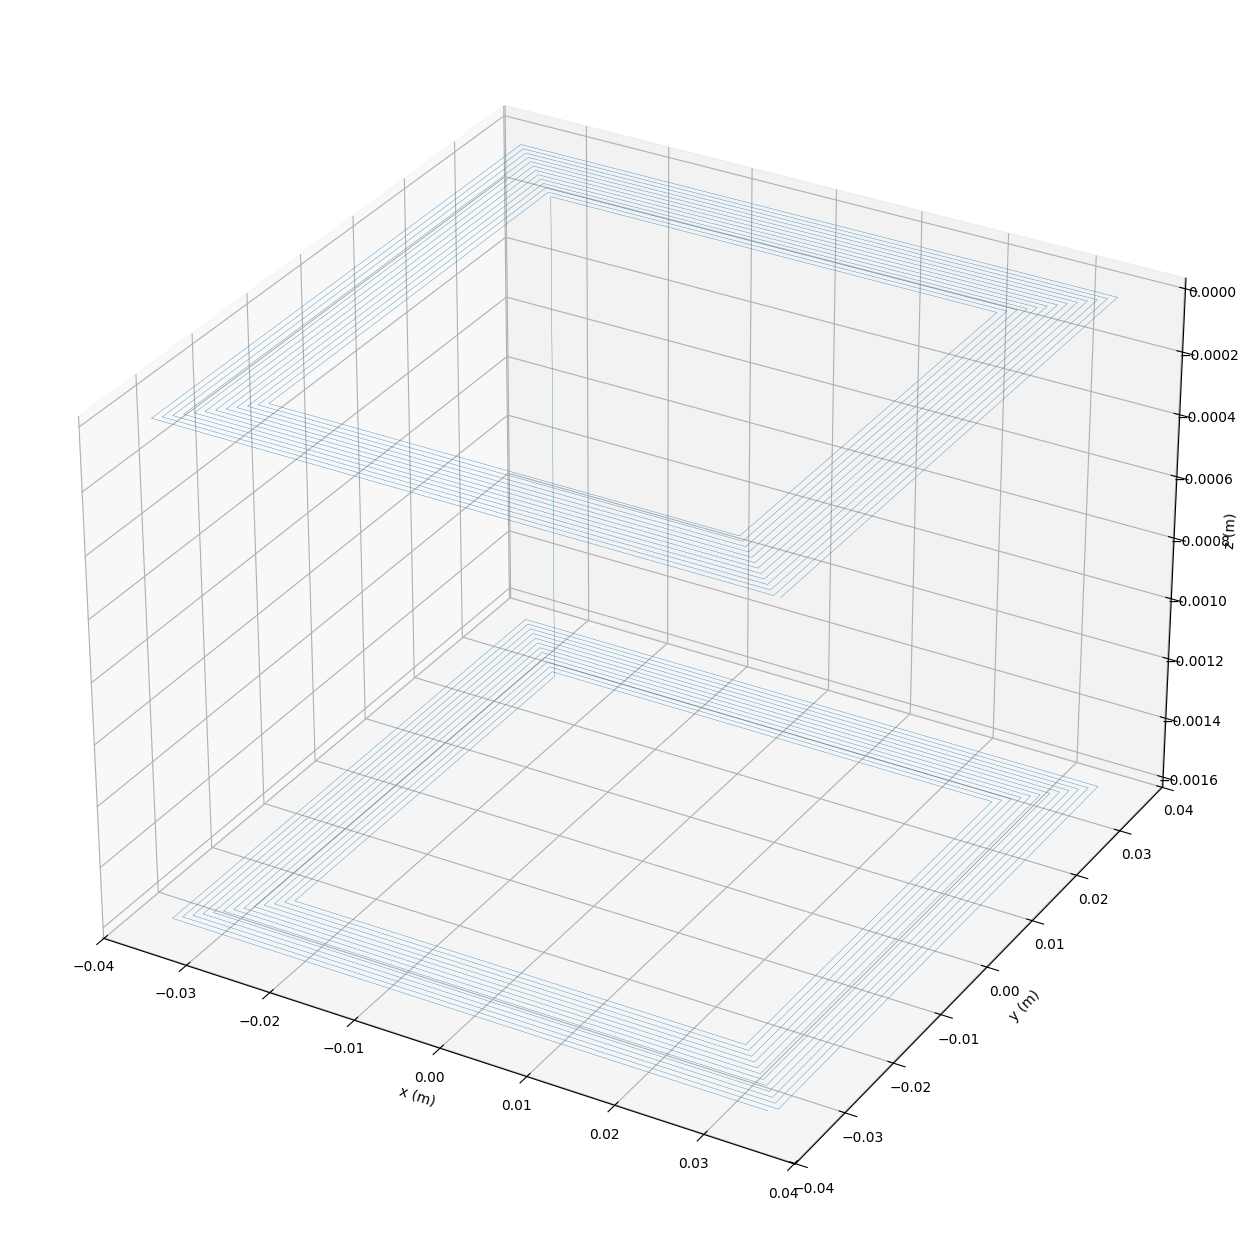

In [3]:
fig = plt.figure(figsize=(16,16))
ax = fig.add_subplot(111, projection='3d')
N = consts.N_turns

ax.plot3D(coil_local[:, 0], coil_local[:, 1], coil_local[:, 2], linewidth=0.25)

ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
plt.show()

### All 8 Coils in Global Coordinate System

In [4]:
coils_global = build_field_generator(consts.N_turns,consts.l,consts.w,consts.s,consts.z_thick,consts.centres,consts.rotations)

In [5]:
print(coils_global.shape)
coils = [f'Coil {i}' for i in range(coils_global.shape[0])]

(8, 102, 3)


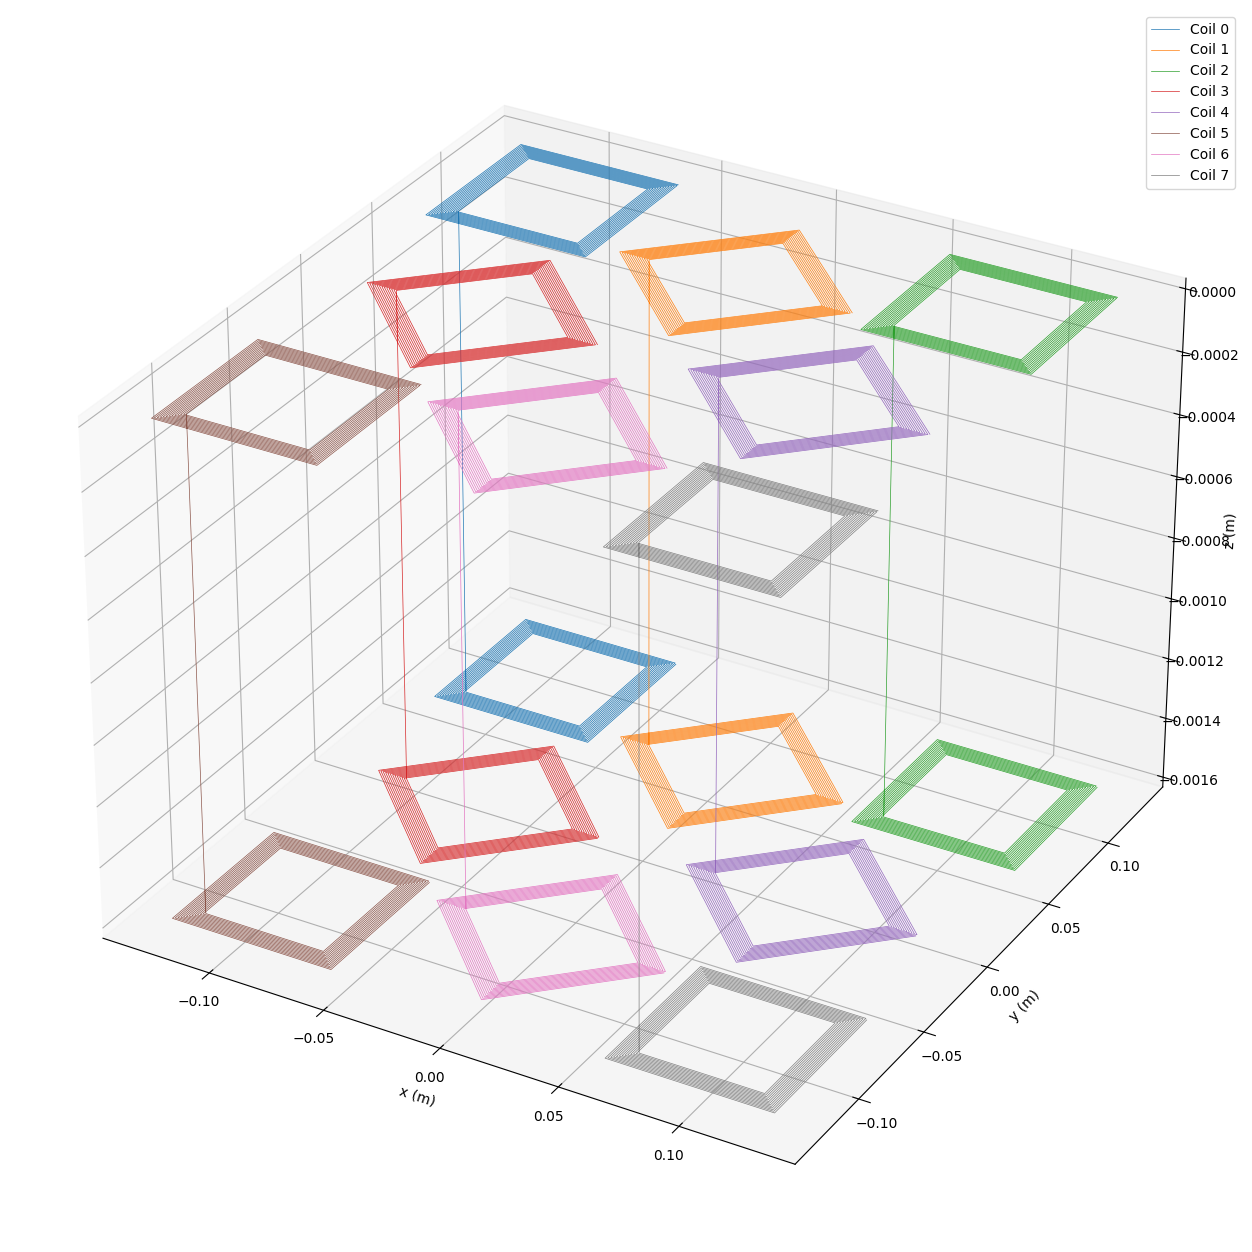

In [6]:
fig = plt.figure(figsize=(16,16))
ax = fig.add_subplot(111, projection='3d')
N = consts.N_turns

for i in range(coils_global.shape[0]):
    ax.plot3D(coils_global[i, :, 0], coils_global[i, :, 1], coils_global[i, :, 2], linewidth=0.5, label = coils[i])

ax.legend()
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
plt.show()

---
## Compute H field at a test point

In [7]:
test_point = np.array([0.05,0.05,0.01])

In [8]:
test_field = field_coil_calc(consts.I, coils_global, test_point)

In [9]:
print(test_field)

[[ -0.51089223   0.15941901   2.32420603]
 [-59.63289817  34.03541301  54.43563681]
 [ 28.30693569  28.16064046  38.94193955]
 [ -0.93742983  -0.39132396   3.74383829]
 [ 33.94547093 -59.59124414  54.89780497]
 [ -0.11000052  -0.10487321   0.92177669]
 [ -0.40618861  -0.92828942   3.74876638]
 [  0.14620048  -0.50674701   2.3303384 ]]


In [10]:
test_field_norm = np.linalg.norm(test_field, axis = -1)

In [11]:
print(test_field_norm)

[ 2.38502809 87.62265938 55.77435733  3.87920537 87.84748354  0.93422202
  3.88329239  2.38927691]


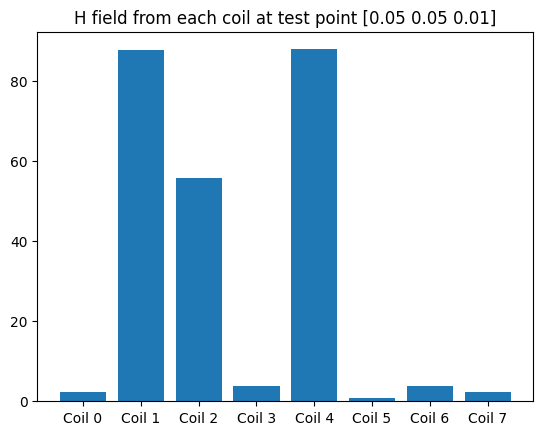

In [12]:
plt.bar(coils,test_field_norm)
plt.title(f'H field from each coil at test point {test_point}')
plt.show()